In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from Camformer import Module, Camformer

In [16]:
#Scaling Tables
# First key (from node) second key (to node) value is the scaling factor
area = {"65": {"45": 0.66, "22":0.15},
        "45": {"22": 0.23}}
energy = {"65": 0.92, "45":0.48, "22":0.23} # @ 1V
delay = {"65": 22.7, "45": 8.092, "22":4.878} # @ 1V
# power scaling law : px = (ex*dy/(ey*dx))*py
def scale_power(from_node, to_node):
    if from_node == to_node:
        return 1
    else:
        return (energy[from_node]*delay[to_node])/(energy[to_node]*delay[from_node])
power = {"65": {"45": scale_power("65", "45"), "22":scale_power("65", "22")},
         "45": {"22": scale_power("45", "22")}}

print(power)


{'65': {'45': 0.6832452276064612, '22': 0.8595594713656389}, '45': {'22': 1.2580541167873798}}


In [17]:
df = pd.read_csv('modules.csv', dtype={'Node (nm)': int, 'Number': int})
modules = {}
for i in df.index:
    pscale = df['Number'][i]
    ascale = df['Number'][i]
    node = df['Node (nm)'][i]
    if node == 65:
        pscale *= (energy['45']/ energy['65'])
        ascale *= area['65']['45']
    module = Module(df['Power (mW)'][i] * pscale , df['Area (um^2)'][i] * ascale, 
                    df['Delay (cycles)'][i])
    modules[df['Module'][i]] = module

# Divide cam by 4 for 16X64 results
modules['BA-CAM 16X64'] = modules['BA-CAM 64X64']
modules['BA-CAM 16X64'].power /= 4
modules['BA-CAM 16X64'].area /= 4

del modules['BA-CAM 64X64']

#Assume programming = searching for now
# modules['cap_cam_64x64'].power2 = modules['cap_cam_64x64'].power 
# modules['cap_cam_64x64'].delay2 = modules['cap_cam_64x64'].delay
modules['BA-CAM 16X64'].power2 = modules['BA-CAM 16X64'].power
modules['BA-CAM 16X64'].delay2 = modules['BA-CAM 16X64'].delay

for k,v in modules.items():
    print(k, v)

Query Buffer Module(power=0.8034782608695652, area=2475.0, delay=1, cycles=0, energy=0, power2=None, delay2=None)
Key SRAM Module(power=28.4, area=27728.6, delay=1, cycles=0, energy=0, power2=None, delay2=None)
6b ADCs Module(power=15.2, area=64000.0, delay=2, cycles=0, energy=0, power2=None, delay2=None)
Fixed Scalers Module(power=0.3923478260869565, area=1338.1632, delay=2, cycles=0, energy=0, power2=None, delay2=None)
Top2 Module(power=6.083673913043478, area=8801.3376924, delay=2, cycles=0, energy=0, power2=None, delay2=None)
Ptop Reg Module(power=1.528695652173913, area=6042.3, delay=1, cycles=0, energy=0, power2=None, delay2=None)
Top32 Module(power=52.077147824347826, area=67016.929254, delay=6, cycles=0, energy=0, power2=None, delay2=None)
SoftMax LUT Module(power=1.418, area=1612.373532, delay=1, cycles=0, energy=0, power2=None, delay2=None)
SoftMax Div. Module(power=0.07109, area=441.529, delay=3, cycles=0, energy=0, power2=None, delay2=None)
SoftMax Acc. Module(power=1.11704

In [18]:
n_par = df.loc[df['Module'] == 'SoftMax Acc.', 'Number'].item()
c_par = df.loc[df['Module'] == 'BF16 MACs', 'Number'].item()
print('n_par', n_par)
print('c_par', c_par)
camformer = Camformer(modules)


n_par 1
c_par 8


In [19]:
print('NO FG PIPELINED')
camformer._run_association(pipelined=False)
camformer._run_normalization(n_par, pipelined=False)
camformer._run_contextualization(c_par, pipelined=False)
print("Cycles: ", camformer.cycles)
print("Latency: ", camformer.cycles * 1e-9, "sec")
print("Energy (nJ): ", camformer.getEnergy())

throughput = 1/(camformer.cycles * 1e-9)
print("NO CG PIPE\tThroughput (att/sec): ", throughput)
print("\t\tPower (mW): ", camformer.getEnergy()/camformer.cycles)

max_stage_cycles = max(camformer.association_cycles, camformer.normalization_cycles, camformer.contextualization_cycles)
print("CG PIPE\t\tThroughput (att/sec): ", 1/(max_stage_cycles * 1e-9))
print("\t\tPower (mW): ", camformer.getEnergy()/max_stage_cycles)

NO FG PIPELINED
Total cycles for association phase: 782
Total cycles for normalization phase: 134
Total cycles for contextualization phase: 1024
Cycles:  1940
Latency:  1.94e-06 sec
Energy (nJ):  35834.76912692529
NO CG PIPE	Throughput (att/sec):  515463.91752577317
		Power (mW):  18.47153047779654
CG PIPE		Throughput (att/sec):  976562.4999999999
		Power (mW):  34.99489172551298


In [20]:
print('ALL FG PIPELINED')
camformer.reset()
camformer._run_association(pipelined=True)
camformer._run_normalization(n_par, pipelined=True)
camformer._run_contextualization(c_par, pipelined=True)
print("Cycles: ", camformer.cycles)
print("Latency: ", camformer.cycles * 1e-9, "sec")
print("Energy (nJ): ", camformer.getEnergy())

throughput = 1/(camformer.cycles * 1e-9)
print("NO CG PIPE\tThroughput (att/sec): ", throughput)
print("\t\tPower (mW): ", camformer.getEnergy()/camformer.cycles)

max_stage_cycles = max(camformer.association_cycles, camformer.normalization_cycles, camformer.contextualization_cycles)
print("CG PIPE\t\tThroughput (att/sec): ", 1/(max_stage_cycles * 1e-9))
print("\t\tPower (mW): ", camformer.getEnergy()/max_stage_cycles)


ALL FG PIPELINED
Total cycles for association phase: 327
Total cycles for normalization phase: 73
Total cycles for contextualization phase: 260
Cycles:  660
Latency:  6.6e-07 sec
Energy (nJ):  35834.76912692529
NO CG PIPE	Throughput (att/sec):  1515151.5151515151
		Power (mW):  54.29510473776559
CG PIPE		Throughput (att/sec):  3058103.9755351683
		Power (mW):  109.58644992943513


In [32]:
print("REALISTIC FG PIPELINED")
camformer.reset()
camformer._run_association(pipelined=True)
camformer._run_normalization(n_par, pipelined=False)
camformer._run_contextualization(c_par, pipelined=True)
print("Cycles: ", camformer.cycles)
print("Latency: ", camformer.cycles * 1e-6, "msec")
print("Energy (nJ): ", camformer.getEnergy())

throughput = 1/(camformer.cycles * 1e-9)
print("NO CG PIPE\tThroughput (att/sec): ", throughput)
print("\t\tPower (mW): ", camformer.getEnergy()/camformer.cycles)

max_stage_cycles = max(camformer.association_cycles, camformer.normalization_cycles, camformer.contextualization_cycles)
print("CG PIPE\t\tThroughput (att/sec): ", 1/(max_stage_cycles * 1e-9))
print("\t\tPower (mW): ", camformer.getEnergy()/max_stage_cycles)
print("DRAM BW Requirement (GB/s): ", (128*64*2 / (max_stage_cycles * 1e-9)) / 1e9)

dram_power = camformer.dram.energy / (max_stage_cycles) # ,W
print("DRAM Power (mW): ", dram_power)

total_power = camformer.getEnergy()/max_stage_cycles + dram_power
print("SC Total Power (W): ", total_power/1000)
print("MC Total Power (W): ", 16*total_power/1000)

total_energy = (camformer.getEnergy() + camformer.dram.energy)*1e-3 # nJ = mW * ns * 1e-3
print("Total Energy (nJ): ", total_energy)

REALISTIC FG PIPELINED
Total cycles for association phase: 327
Total cycles for normalization phase: 134
Total cycles for contextualization phase: 260
Cycles:  721
Latency:  0.000721 msec
Energy (nJ):  35834.76912692529
NO CG PIPE	Throughput (att/sec):  1386962.5520110957
		Power (mW):  49.701482839008726
CG PIPE		Throughput (att/sec):  3058103.9755351683
		Power (mW):  109.58644992943513
DRAM BW Requirement (GB/s):  50.103975535168196
DRAM Power (mW):  58.37113151412851
SC Total Power (W):  0.16795758144356365
MC Total Power (W):  2.6873213030970184
Total Energy (nJ):  54.92212913204532


In [22]:
eff_op = (2*64*1024) + 2*(1024) + (2*64*1024)
sc_gops = ( eff_op / (max_stage_cycles * 1e-9) ) / 1e9
print("SC Eff Gops/sec: ", sc_gops)
print("SC Eff Tops/sec: ", sc_gops/1e3)
watt = camformer.getEnergy()/max_stage_cycles/1e3
print("SC Eff Top/sec/Watt: ", (sc_gops/1e3)/(watt))

sc_tput = 1/(max_stage_cycles * 1e-9 * 16) 
print("Single-core MHA Throughput (att/msec): ", sc_tput/1e3)
mc_tput = 1/(max_stage_cycles * 1e-9)
print("Multi-core MHA Throughput (att/msec): ", mc_tput/1e3)
print("Single- Multi-Core MHA Energy Efficiency (att/joule): ", 1/(16*total_energy/1e9))
print("Single- Multi-Core MHA Energy Efficiency (att/joule): ", sc_tput / (total_power*1e-3))


SC Eff Gops/sec:  807.9266055045872
SC Eff Tops/sec:  0.8079266055045872
SC Eff Top/sec/Watt:  7.372504593632032
Single-core MHA Throughput (att/msec):  191.13149847094803
Multi-core MHA Throughput (att/msec):  3058.1039755351685
Single- Multi-Core MHA Energy Efficiency (att/joule):  1137974.8197622811
Single- Multi-Core MHA Energy Efficiency (att/joule):  1137974.8197622811


In [23]:


spatten_gops = 360
a3_gops = 221
mnnfst_gops = 120
spatten_gop_pj = 382
a3_gop_p2 = 269
mnnfst_gop_pj = 120

spatten_tput = (spatten_gops/(16*eff_op/1e9)) # mha att/sec
print("Spatten MHA Throughput (att/msec): ", spatten_tput/1e3)
a3_tput = (a3_gops/(16*eff_op/1e9)) # mha att/sec
print("A3 MHA Throughput (att/msec): ", a3_tput/1e3)
mnnfst_tput = (mnnfst_gops/(16*eff_op/1e9)) # mha att/sec
print("MNNFST MHA Throughput (att/msec): ", mnnfst_tput/1e3)
spatten_eneff = (spatten_gop_pj)/(16*eff_op/1e9) # mha att/joule
print("Spatten MHA Energy Efficiency (att/joule): ", spatten_eneff)
a3_eneff = (a3_gop_p2)/(16*eff_op/1e9) # mha att/joule  
print("A3 MHA Energy Efficiency (att/joule): ", a3_eneff)
mnnfst_eneff = (mnnfst_gop_pj)/(16*eff_op/1e9) # mha att/joule
print("MNNFST MHA Energy Efficiency (att/joule): ", mnnfst_eneff)

print("Spatten Pwr (W): ", spatten_gops/spatten_gop_pj)
print("A3 Pwr (W): ", a3_gops/a3_gop_p2)
print("MNNFST Pwr (W): ", mnnfst_gops/mnnfst_gop_pj)


Spatten MHA Throughput (att/msec):  85.16533430232558
A3 MHA Throughput (att/msec):  52.28205244670543
MNNFST MHA Throughput (att/msec):  28.388444767441857
Spatten MHA Energy Efficiency (att/joule):  90369.88250968992
A3 MHA Energy Efficiency (att/joule):  63637.43035368217
MNNFST MHA Energy Efficiency (att/joule):  28388.44476744186
Spatten Pwr (W):  0.9424083769633508
A3 Pwr (W):  0.8215613382899628
MNNFST Pwr (W):  1.0


In [24]:
# Energy breakdown by module
for module_name, module in modules.items():
    print(f"{module_name} - Energy (nJ): {module.energy:.2f}")

Query Buffer - Energy (nJ): 52.23
Key SRAM - Energy (nJ): 7270.40
6b ADCs - Energy (nJ): 1945.60
Fixed Scalers - Energy (nJ): 50.22
Top2 - Energy (nJ): 778.71
Ptop Reg - Energy (nJ): 100.89
Top32 - Energy (nJ): 937.39
SoftMax LUT - Energy (nJ): 45.38
SoftMax Div. - Energy (nJ): 6.82
SoftMax Acc. - Energy (nJ): 35.75
Output Buff - Energy (nJ): 149.26
Value SRAM - Energy (nJ): 11104.00
BF16 MACs - Energy (nJ): 9150.82
DRAM - Energy (nJ): 19087.36
BA-CAM 16X64 - Energy (nJ): 4207.30


In [25]:
# Total area and breakdown by module
total_area = sum(module.area for module in modules.values())
print(f"Total Area (um^2/mm^2): {total_area:.0f}/{total_area/1e6:.6f}")
# Area breakdown by module
for module_name, module in modules.items():
    print(f"{module_name} - Area (um^2): {module.area:.2f}")

print(f"MHA Area (um^2): {16*total_area/1e6:.6f}")
total_area = total_area/1e6 # convert to mm^2

Total Area (um^2/mm^2): 258414/0.258414
Query Buffer - Area (um^2): 2475.00
Key SRAM - Area (um^2): 27728.60
6b ADCs - Area (um^2): 64000.00
Fixed Scalers - Area (um^2): 1338.16
Top2 - Area (um^2): 8801.34
Ptop Reg - Area (um^2): 6042.30
Top32 - Area (um^2): 67016.93
SoftMax LUT - Area (um^2): 1612.37
SoftMax Div. - Area (um^2): 441.53
SoftMax Acc. - Area (um^2): 2879.58
Output Buff - Area (um^2): 5990.82
Value SRAM - Area (um^2): 44820.00
BF16 MACs - Area (um^2): 23036.64
DRAM - Area (um^2): 0.00
BA-CAM 16X64 - Area (um^2): 2230.27
MHA Area (um^2): 4.134617


{'gops': 7500000.0, 'area': 46225, 'power': 25593.12}
{'gops': 205000.0, 'area': 725, 'power': 300}


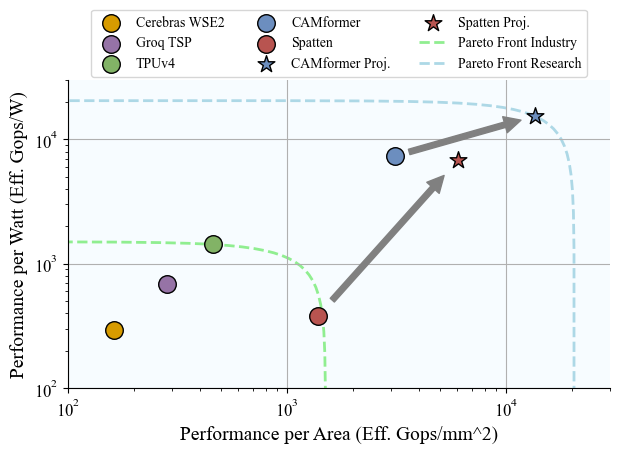

In [76]:
marker_size = 160  # tweak this parameter to change marker sizes
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'
# Cerebras WSE2 from HotChips 34 (7nm)
cerebras = {
    'gops': 7.5e6, # 7.5Pflops peak
    'area': 215*215, # mm^2
    'power': (30e-3)*10156*84, # 30mW/core * 10156 cores/tile * 84tiles
}
print(cerebras)

# Groq TSP Microprocessor report (Groq rocks neural nets) (14nm)
groq = {
    'gops': 205e3, # 205Tops
    'area': 725, # mm^2
    'power': 300, # W
}
print(groq)

# TPUv4 from TPUv4 paper (7nm)
tpuv4 = {
    'gops': 275e3, # 275Tops
    'area': 600, # mm^2
    'power': 192, # W
}

colors = {
    'CAMformer': '#6C8EBF',
    'Spatten': '#B85450',
    'Cerebras WSE2': '#D79B00',
    'Groq TSP': '#9673A6',
    'TPUv4': '#82B366'
}

# Plot gops per area vs gops per power
total_power = camformer.getEnergy()/(max_stage_cycles * 1000)
plt.figure(figsize=(7, 4))
plt.scatter(cerebras['gops']/cerebras['area'], cerebras['gops']/cerebras['power'], 
            s=marker_size, label='Cerebras WSE2', c=colors['Cerebras WSE2'],edgecolors='black')
plt.scatter(groq['gops']/groq['area'], groq['gops']/groq['power'], 
            s=marker_size, label='Groq TSP', c=colors['Groq TSP'],edgecolors='black')
plt.scatter(tpuv4['gops']/tpuv4['area'], tpuv4['gops']/tpuv4['power'], 
            s=marker_size, label='TPUv4', zorder=2, c=colors['TPUv4'],edgecolors='black')
plt.scatter(sc_gops/total_area, sc_gops/total_power, 
            s=marker_size, label='CAMformer', c=colors['CAMformer'], zorder=2,edgecolors='black')
plt.scatter(spatten_gops/total_area, spatten_gop_pj, 
            s=marker_size, label='Spatten', c=colors['Spatten'], zorder=2,edgecolors='black')

# Camformer at 22nm
c22_x = sc_gops/(total_area*area['45']['22'])
c22_y = sc_gops/(total_power*(energy['22']/energy['45']))
plt.scatter(c22_x, c22_y, s=marker_size, label='CAMformer Proj.', marker='*', zorder=2, c=colors['CAMformer'],edgecolors='black')
# Draw arrow from Camformer to 22nm
plt.annotate('', xy=(c22_x, c22_y), xytext=(sc_gops/total_area, sc_gops/total_power),
             arrowprops=dict( lw=1, shrink=0.1, color='gray'),)
# Spatten at 22nm
s22_x = spatten_gops/(total_area*area['45']['22'])
s22_y = spatten_gops/(total_power*(energy['22']/energy['45']))
plt.scatter(s22_x, s22_y, s=marker_size, label='Spatten Proj.', marker='*', c=colors['Spatten'],edgecolors='black')
# Draw arrow from Spatten to 22nm
plt.annotate('', xy=(s22_x, s22_y), xytext=(spatten_gops/total_area, spatten_gop_pj),
             arrowprops=dict( lw=1, shrink=0.1, color='gray'))

# Plot pareto front @ TPUv4 (industry)
tpuv4_radius = np.sqrt((tpuv4['gops']/tpuv4['area'])**2 + (tpuv4['gops']/tpuv4['power'])**2)
t = np.linspace(0, 2*np.pi, 100)
x = tpuv4_radius * np.cos(t)
y = tpuv4_radius * np.sin(t)
plt.plot(x, y, label='Pareto Front Industry', color='lightgreen', linestyle='--', linewidth=2, zorder=1)

# Plot pareto front @ Camformer22 (research)
c22_radius = np.sqrt((c22_x)**2 + (c22_y)**2)
t = np.linspace(0, 2*np.pi, 100)
x = c22_radius * np.cos(t)
y = c22_radius * np.sin(t)
plt.plot(x, y, label='Pareto Front Research', color='lightblue', linestyle='--', linewidth=2, zorder=1)

# Change facecolor of plot
plt.gca().set_facecolor('#f7fcff')

plt.xlabel('Performance per Area (Eff. Gops/mm^2)', fontsize=14)
plt.ylabel('Performance per Watt (Eff. Gops/W)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e2, 3e4)
plt.ylim(1e2, 3e4)
plt.legend(ncol=3, fontsize=10, loc='center', bbox_to_anchor=(0.5, 1.12))
plt.grid()
# Show only the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().get_ygridlines()[4].set_visible(False)
plt.savefig('pareto_front.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
module_groupings = {
    "Association": ["BA-CAM 16X64", "Query Buffer", "Key SRAM", "6b ADCs", "Fixed Scalers", "Top2", "Ptop Reg"],
    "Normalization": ["Top32", "SoftMax LUT", "SoftMax Div.", "SoftMax Acc.", "Output Buff"],
    "Contextualization": ["BF16 MACs", "Value SRAM"],
}

[14405.355130434771, 1174.5938225773912, 20254.820173913125]
[4207.304347826106, 52.22608695652178, 7270.399999999969, 1945.6000000000022, 50.22052173913048, 778.7102608695645, 100.8939130434782, 937.3886608382609, 45.37599999999998, 6.824639999999996, 35.745391304347805, 149.25913043478252, 9150.820173913096, 11104.000000000031]


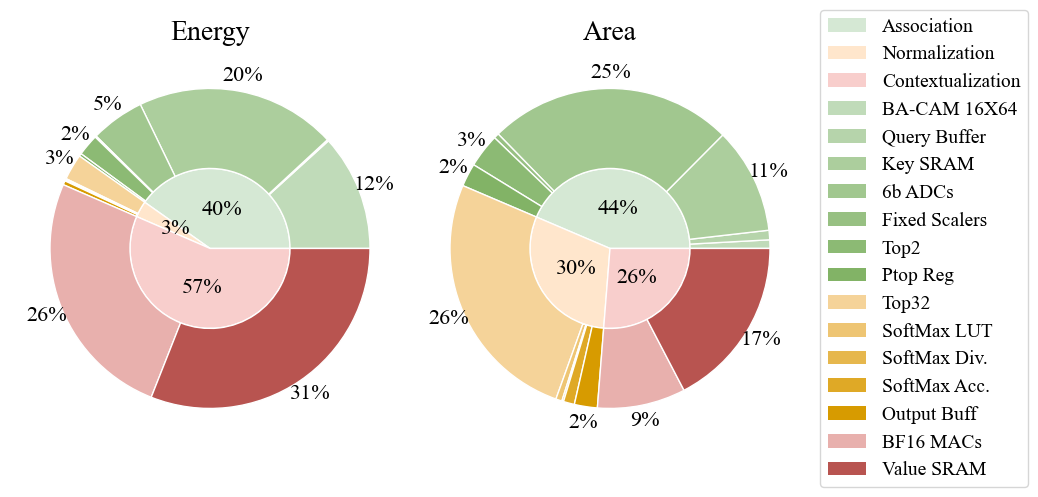

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


# Define custom color ranges for each group.
# For Association, the gradient goes from dark green to light green.
# For Normalization, the gradient goes from light yellow to dark yellow.
# For Contextualization, the gradient goes from light red to dark red.
color_config = {
    "Association": {
        "end": np.array([130, 179, 102]) / 255.0,   # dark green
        "start": np.array([213, 232, 212]) / 255.0        # light green
    },
    "Normalization": {
        "start": np.array([255, 230, 204]) / 255.0,     # light yellow
        "end": np.array([215, 155, 0]) / 255.0           # dark yellow
    },
    "Contextualization": {
        "start": np.array([248, 206, 204]) / 255.0,     # light red
        "end": np.array([184, 84, 80]) / 255.0           # dark red
    }
}

# Constant for ring width in the nested pie charts
size = 0.5

def gradient_color(group, index, total):
    """Return a gradient color for the given group, index, and total count.
       The fraction goes from 0.1 to 1.0.
    """
    fraction = 0.25 + (index / (total - 1)) * 0.75 if total > 1 else 1.0
    config = color_config[group]
    return config["start"] * (1 - fraction) + config["end"] * fraction

# =========================
# Prepare Energy Data
# =========================
outer_energy = []
outer_labels = []
inner_energy = []
inner_labels = []
inner_colors_energy = []

for group in module_groupings:
    group_modules = [mod for mod in module_groupings[group] if mod in modules]
    group_energy = sum(modules[mod].energy for mod in group_modules)
    outer_energy.append(group_energy)
    outer_labels.append(group)
    m = len(group_modules)
    for i, mod in enumerate(group_modules):
        inner_energy.append(modules[mod].energy)
        inner_labels.append(mod)
        inner_colors_energy.append(gradient_color(group, i, m))
print(outer_energy)
print(inner_energy)

# Use the start (dark) color for each group as the outer colors
outer_colors_energy = [color_config[group]["start"] for group in module_groupings]

# =========================
# Prepare Area Data
# =========================
outer_area = []
outer_area_labels = []
inner_area = []
inner_labels_area = []
inner_colors_area = []

for group in module_groupings:
    group_modules = [mod for mod in module_groupings[group] if mod in modules]
    group_area = sum(modules[mod].area for mod in group_modules)
    outer_area.append(group_area)
    outer_area_labels.append(group)
    m = len(group_modules)
    for i, mod in enumerate(group_modules):
        inner_area.append(modules[mod].area)
        inner_labels_area.append(mod)
        inner_colors_area.append(gradient_color(group, i, m))

# Use the same dark color for outer ring as provided by the group config
outer_colors_area = [color_config[group]["start"] for group in module_groupings]

# =========================
# Create the nested pie charts
# =========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), subplot_kw=dict(aspect="equal"))
plt.subplots_adjust(wspace=0,top=1, bottom=0, left=0, right=1)

pct_fmt = '%1.1f%%'
pct_fmt = None
pct_fmt = lambda pct: f'{pct:.0f}%' if pct > 2 else ''
rot =0
# --- Nested Pie Chart for Energy ---
ax1.pie(outer_energy, radius=1 - size, colors=outer_colors_energy, textprops={'size': 16},
        wedgeprops=dict(width=size, edgecolor='w'), autopct=pct_fmt, pctdistance=0.5, startangle=rot,)
ax1.pie(inner_energy, radius=1, colors=inner_colors_energy,textprops={'size': 16},
        wedgeprops=dict(width=size, edgecolor='w'), autopct=pct_fmt, pctdistance=1.1, startangle=rot)
ax1.set_title('Energy', fontsize=20)


# --- Nested Pie Chart for Area ---
ax2.pie(outer_area, radius=1 - size, colors=outer_colors_area,textprops={'size': 16},
        wedgeprops=dict(width=size, edgecolor='w'), autopct=pct_fmt, pctdistance=0.5)
ax2.pie(inner_area, radius=1, colors=inner_colors_area,textprops={'size': 16},
        wedgeprops=dict(width=size, edgecolor='w'), autopct=pct_fmt, pctdistance=1.1)
ax2.set_title('Area', fontsize=20)

legend_patches = ([Patch(facecolor=outer_colors_area[i], label=outer_area_labels[i])
                 for i in range(len(outer_area_labels))] +
                [Patch(facecolor=inner_colors_area[i], label=inner_labels_area[i])
                 for i in range(len(inner_labels_area))])
ax2.legend(handles=legend_patches, loc="center left", bbox_to_anchor=(1, 0.5), ncol=1, fontsize=14)

plt.savefig('area_energy_breakdown.png', bbox_inches='tight', dpi=300)
plt.show()